In [7]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import patheffects

plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置字体为黑体  
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

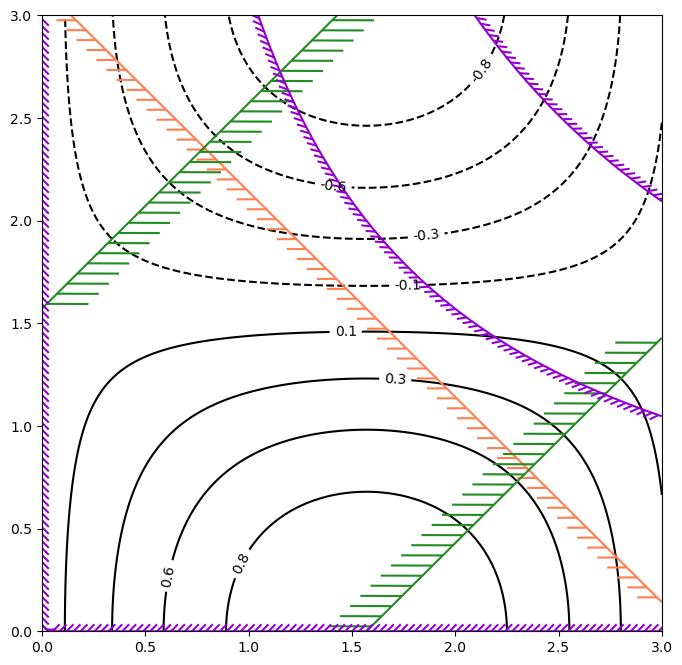

In [1]:
# 创建图形和坐标轴
fig, ax = plt.subplots(figsize=(8, 8))

# 网格大小
nx = 101
ny = 101

# 设置网格向量
xvec = np.linspace(0.0, 3.0, nx)
yvec = np.linspace(0.0, 3.0, ny)

# 创建网格矩阵
x1, x2 = np.meshgrid(xvec, yvec)

# 计算数据
obj = np.sin(x1) * np.cos(x2)
g1 = np.sin(x1 + x2)
g2 = np.cos(x1 - x2)
g3 = np.sin(x1 * x2)

# 绘制等高线图
cntr = ax.contour(x1, x2, obj, levels=np.linspace(-1, 1, 10), colors='black')
ax.clabel(cntr, fmt="%1.1f", use_clabeltext=True)

# 绘制不同颜色和效果的等高线
cg1 = ax.contour(x1, x2, g1, [0], colors='coral')
cg1.set(path_effects=[patheffects.withTickedStroke(angle=45)])

cg2 = ax.contour(x1, x2, g2, [0], colors='forestgreen')
cg2.set(path_effects=[patheffects.withTickedStroke(angle=135, length=3)])

cg3 = ax.contour(x1, x2, g3, [0], colors='darkviolet')
cg3.set(path_effects=[patheffects.withTickedStroke(spacing=5)])

# 设置坐标轴范围
ax.set_xlim(0, 3)
ax.set_ylim(0, 3)

# 显示图形
plt.show()


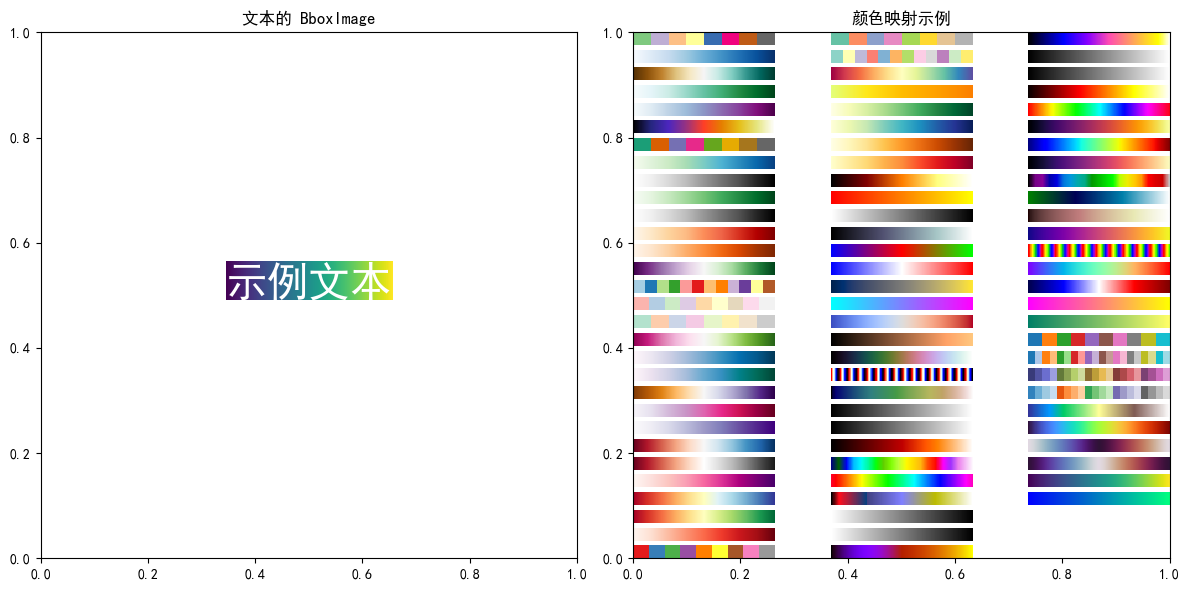

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.image import BboxImage
from matplotlib.transforms import Bbox, TransformedBbox

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))

# ---------------------------
# 创建包含文本的 BboxImage
# ---------------------------
txt = ax1.text(0.5, 0.5, "示例文本", size=30, ha="center", color="white")
# 使用 BboxImage 创建一个包含文本的图像
bbox_image = BboxImage(txt.get_window_extent, data=np.arange(256).reshape((1, -1)))
ax1.add_artist(bbox_image)
ax1.set_title("文本的 BboxImage")

# -----------------------------
# 为每个颜色映射创建 BboxImage
# -----------------------------
# 所有颜色映射的列表，跳过反转的颜色映射
cmap_names = sorted(m for m in plt.colormaps if not m.endswith("_r"))

ncol = 3  # 列数
nrow = len(cmap_names) // ncol + 1  # 行数

xpad_fraction = 0.4  # 列间距
dx = 1 / (ncol + xpad_fraction * (ncol - 1))

ypad_fraction = 0.4  # 行间距
dy = 1 / (nrow + ypad_fraction * (nrow - 1))

for i, cmap_name in enumerate(cmap_names):
    ix, iy = divmod(i, nrow)
    bbox0 = Bbox.from_bounds(ix * dx * (1 + xpad_fraction),
                             1 - iy * dy * (1 + ypad_fraction) - dy,
                             dx, dy)
    bbox = TransformedBbox(bbox0, ax2.transAxes)
    # 为每个颜色映射创建一个 BboxImage
    bbox_image = BboxImage(bbox, cmap=cmap_name, data=np.arange(256).reshape((1, -1)))
    ax2.add_artist(bbox_image)

ax2.set_title("颜色映射示例")

plt.tight_layout()
plt.show()


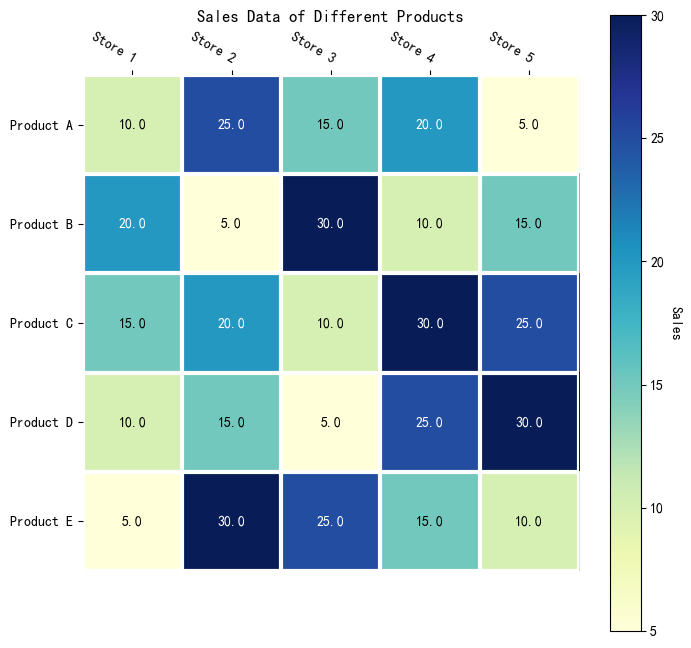

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl


def heatmap(data, row_labels, col_labels, ax=None, 
            cbar_kw=None, cbarlabel="", **kwargs):
    """
    创建一个热图

    参数
    ----------
    data : numpy array
        形状为 (M, N) 的二维数组。
    row_labels : list or array
        长度为 M 的行标签。
    col_labels : list or array
        长度为 N 的列标签。
    ax : matplotlib.axes.Axes, optional
        绘制热图的 Axes 实例。如果未提供，将使用当前 Axes 或创建一个新的。可选。
    cbar_kw : dict, optional
        传递给 `matplotlib.Figure.colorbar` 的参数字典。可选。
    cbarlabel : str, optional
        colorbar 的标签。可选。
    **kwargs
        传递给 `imshow` 的其他参数。
    """
    if ax is None:
        ax = plt.gca()

    if cbar_kw is None:
        cbar_kw = {}

    # 绘制热图
    im = ax.imshow(data, **kwargs)

    # 创建 colorbar
    cbar = ax.figure.colorbar(im, ax=ax, **cbar_kw)
    cbar.ax.set_ylabel(cbarlabel, rotation=-90, va="bottom")

    # 显示所有刻度并用相应的标签标记
    ax.set_xticks(np.arange(data.shape[1]), labels=col_labels)
    ax.set_yticks(np.arange(data.shape[0]), labels=row_labels)

    # 将水平轴标签显示在顶部
    ax.tick_params(top=True, bottom=False,
                   labeltop=True, labelbottom=False)

    # 旋转刻度标签并设置对齐方式
    plt.setp(ax.get_xticklabels(), rotation=-30, ha="right",
             rotation_mode="anchor")

    # 关闭脊线并创建白色网格
    ax.spines[:].set_visible(False)
    ax.set_xticks(np.arange(data.shape[1]+1)-.5, minor=True)
    ax.set_yticks(np.arange(data.shape[0]+1)-.5, minor=True)
    ax.grid(which="minor", color="w", linestyle='-', linewidth=3)
    ax.tick_params(which="minor", bottom=False, left=False)

    return im, cbar

def annotate_heatmap(im, data=None, valfmt="{x:.2f}",
                     textcolors=("black", "white"),
                     threshold=None, **textkw):
    """
    为热图添加注释

    参数
    ----------
    im : AxesImage
        要标记的 AxesImage。
    data : array-like, optional
        用于注释的数据。如果为 None，则使用图像的数据。可选。
    valfmt : str or matplotlib.ticker.Formatter, optional
        热图内注释的格式。这应该使用字符串格式方法，例如 "$ {x:.2f}"，或者是 `matplotlib.ticker.Formatter`。可选。
    textcolors : tuple of str, optional
        一对颜色。第一个用于阈值以下的值，第二个用于阈值以上的值。可选。
    threshold : float, optional
        根据数据单位的阈值应用 textcolors 的颜色。如果为 None（默认），则使用 colormap 的中间值作为分隔。可选。
    **textkw
        传递给每个 `text` 调用的其他参数。
    """
    if not isinstance(data, (list, np.ndarray)):
        data = im.get_array()

    # 归一化阈值到图像的颜色范围
    if threshold is not None:
        threshold = im.norm(threshold)
    else:
        threshold = im.norm(data.max())/2.

    # 设置默认对齐方式为中心，但可以通过 textkw 覆盖
    kw = dict(horizontalalignment="center",
              verticalalignment="center")
    kw.update(textkw)

    # 获取格式化程序以防字符串被提供
    if isinstance(valfmt, str):
        valfmt = mpl.ticker.StrMethodFormatter(valfmt)

    # 遍历数据并为每个“像素”创建一个 `Text`
    # 根据数据改变文本的颜色
    texts = []
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            kw.update(color=textcolors[int(im.norm(data[i, j]) > threshold)])
            text = im.axes.text(j, i, valfmt(data[i, j], None), **kw)
            texts.append(text)

    return texts
    
# 新的数据和标签
products = ["Product A", "Product B", "Product C", "Product D", "Product E"]
stores = ["Store 1", "Store 2", "Store 3", "Store 4", "Store 5"]

# 销售数据
sales = np.array([[10, 25, 15, 20, 5],
                  [20, 5, 30, 10, 15],
                  [15, 20, 10, 30, 25],
                  [10, 15, 5, 25, 30],
                  [5, 30, 25, 15, 10]])

# 创建图形和轴
fig, ax = plt.subplots(figsize=(8, 8))

# 创建热图
im, cbar = heatmap(sales, products, stores, ax=ax, cmap="YlGnBu", cbarlabel="Sales")

# 添加注释
annotate_heatmap(im, data=sales, valfmt="{x:.1f}")

# 设置标题
ax.set_title("Sales Data of Different Products")

plt.show()






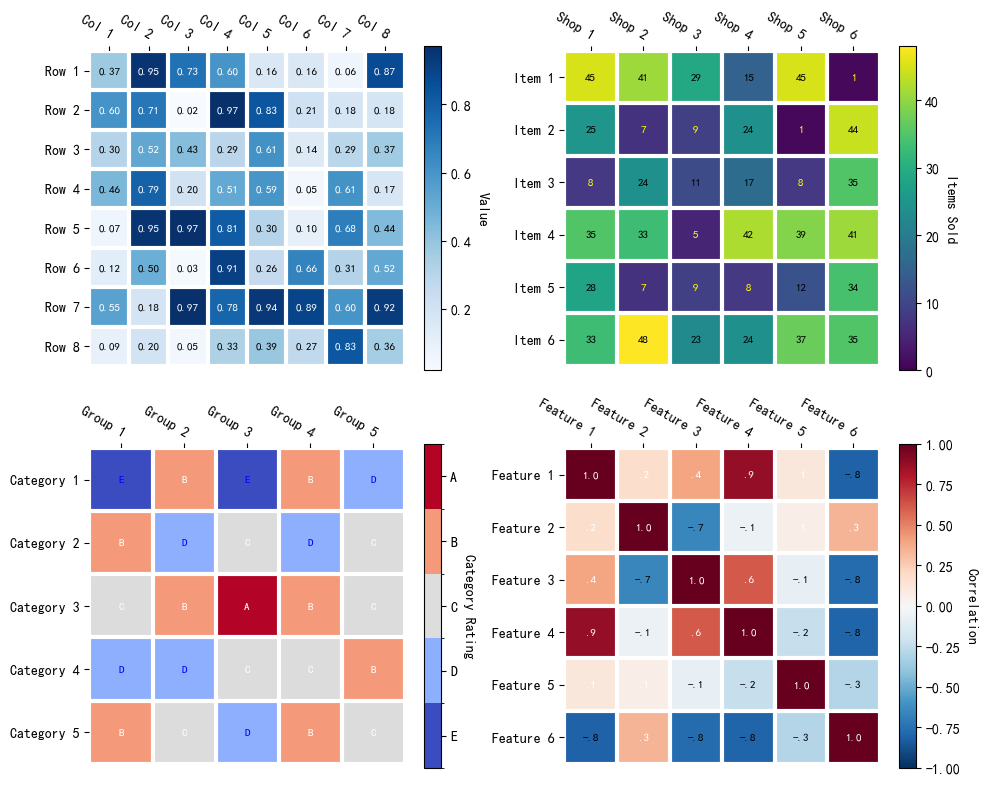

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

# 设置随机种子以确保结果一致
np.random.seed(42)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 8))

# ----------------------------
# 示例 1: 使用不同的字体大小和颜色映射绘制热图
# ----------------------------
# 创建示例数据
data1 = np.random.rand(8, 8)
rows1 = [f"Row {i}" for i in range(1, 9)]
cols1 = [f"Col {i}" for i in range(1, 9)]

# 绘制热图
im1, _ = heatmap(data1, rows1, cols1, ax=ax1, cmap="Blues", cbarlabel="Value")
annotate_heatmap(im1, valfmt="{x:.2f}", size=8)

# ----------------------------
# 示例 2: 使用整数格式和不同的颜色绘制热图
# ----------------------------
# 创建示例数据
data2 = np.random.randint(1, 50, size=(6, 6))
rows2 = [f"Item {i}" for i in range(1, 7)]
cols2 = [f"Shop {i}" for i in range(1, 7)]

# 绘制热图
im2, _ = heatmap(data2, rows2, cols2, ax=ax2, vmin=0, cmap="viridis", cbarlabel="Items Sold")
annotate_heatmap(im2, valfmt="{x:d}", size=8, threshold=10, textcolors=("yellow", "black"))

# ----------------------------
# 示例 3: 分类数据热图
# ----------------------------
# 创建示例数据
data3 = np.random.randn(5, 5)
rows3 = [f"Category {i}" for i in range(1, 6)]
cols3 = [f"Group {i}" for i in range(1, 6)]

# 定义分类和颜色映射
categories = list("ABCDE")
norm = matplotlib.colors.BoundaryNorm(np.linspace(-2.5, 2.5, 6), 5)
fmt = matplotlib.ticker.FuncFormatter(lambda x, pos: categories[::-1][norm(x)])

# 绘制热图
im3, _ = heatmap(data3, rows3, cols3, ax=ax3,
                 cmap=mpl.colormaps["coolwarm"].resampled(5), norm=norm,
                 cbar_kw=dict(ticks=np.arange(-2, 3), format=fmt),
                 cbarlabel="Category Rating")

annotate_heatmap(im3, valfmt=fmt, size=8, fontweight="bold", threshold=-1,
                 textcolors=("blue", "white"))

# ----------------------------
# 示例 4: 相关矩阵热图
# ----------------------------
# 创建示例数据
data4 = np.random.rand(6, 6)
corr_matrix = np.corrcoef(data4)

# 绘制热图
im4, _ = heatmap(corr_matrix, [f"Feature {i}" for i in range(1, 7)],
                 [f"Feature {i}" for i in range(1, 7)], ax=ax4,
                 cmap="RdBu_r", vmin=-1, vmax=1,
                 cbarlabel="Correlation")

# 自定义格式化函数
def custom_func(x, pos):
    return f"{x:.1f}".replace("0.", ".")

annotate_heatmap(im4, valfmt=matplotlib.ticker.FuncFormatter(custom_func), size=8)

plt.tight_layout()
plt.show()

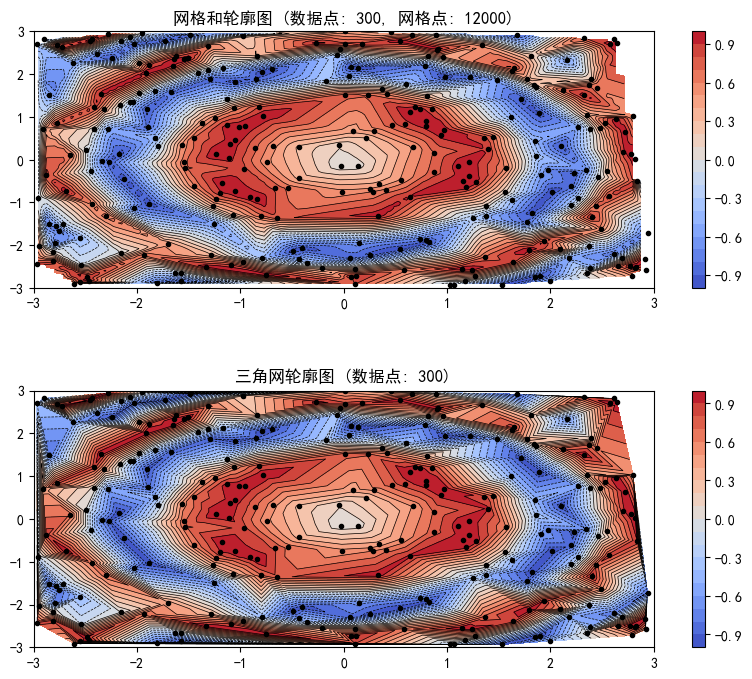

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.tri as tri

# 设置随机种子以确保结果一致
np.random.seed(42)

# 修改后的数据
npts = 300
ngridx = 80
ngridy = 150
x = np.random.uniform(-3, 3, npts)
y = np.random.uniform(-3, 3, npts)
z = np.sin(x**2 + y**2)  # 修改为使用 sin 函数

fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(10, 8))

# -------------------------
# 网格上的插值绘图
# -------------------------
# 通过网格插值绘制不规则间距数据坐标的轮廓图

# 创建网格数据
xi = np.linspace(-3.2, 3.2, ngridx)
yi = np.linspace(-3.2, 3.2, ngridy)

# 在 (xi, yi) 定义的网格上进行线性插值
triang = tri.Triangulation(x, y)
interpolator = tri.LinearTriInterpolator(triang, z)
Xi, Yi = np.meshgrid(xi, yi)
zi = interpolator(Xi, Yi)

# 使用 SciPy 的 griddata 进行插值的替代方法
# from scipy.interpolate import griddata
# zi = griddata((x, y), z, (xi[None, :], yi[:, None]), method='linear')

# 绘制插值网格上的轮廓图
ax1.contour(xi, yi, zi, levels=20, linewidths=0.5, colors='black')
cntr1 = ax1.contourf(xi, yi, zi, levels=20, cmap="coolwarm")

# 添加颜色条
fig.colorbar(cntr1, ax=ax1)
ax1.plot(x, y, 'ko', markersize=3)
ax1.set_xlim(-3, 3)
ax1.set_ylim(-3, 3)
ax1.set_title('网格和轮廓图 (数据点: %d, 网格点: %d)' % (npts, ngridx * ngridy))

# ------------------------
# 不规则数据的三角网轮廓图
# ------------------------
# 直接将无序的、不规则间距的坐标传递给 tricontour

ax2.tricontour(x, y, z, levels=20, linewidths=0.5, colors='black')
cntr2 = ax2.tricontourf(x, y, z, levels=20, cmap="coolwarm")

# 添加颜色条
fig.colorbar(cntr2, ax=ax2)
ax2.plot(x, y, 'ko', markersize=3)
ax2.set_xlim(-3, 3)
ax2.set_ylim(-3, 3)
ax2.set_title('三角网轮廓图 (数据点: %d)' % npts)

plt.subplots_adjust(hspace=0.4)
plt.show()


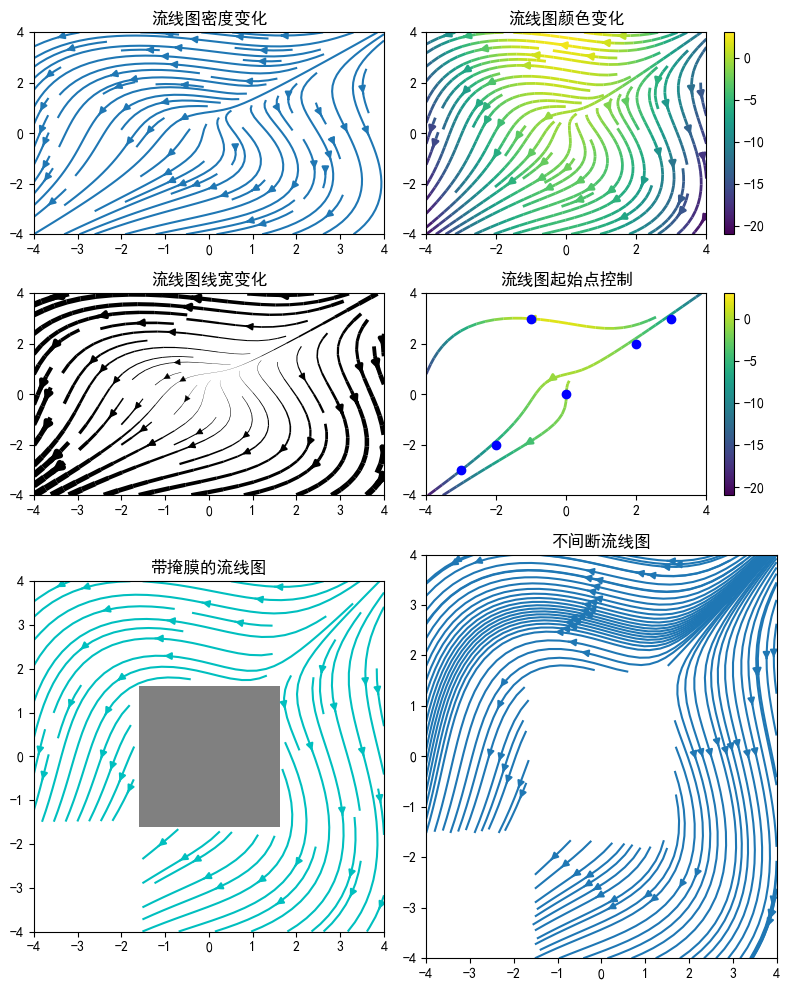

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# 设置网格范围和分辨率
w = 4
Y, X = np.mgrid[-w:w:100j, -w:w:100j]
U = X - Y**2
V = -1 - X**2 + Y
speed = np.sqrt(U**2 + V**2)

fig, axs = plt.subplots(3, 2, figsize=(8, 10), height_ratios=[1, 1, 2])
axs = axs.flat

# 变密度的流线图
axs[0].streamplot(X, Y, U, V, density=[0.8, 1.2])
axs[0].set_title('流线图密度变化')

# 变颜色的流线图
strm = axs[1].streamplot(X, Y, U, V, color=V, linewidth=2, cmap='viridis')
fig.colorbar(strm.lines)
axs[1].set_title('流线图颜色变化')

# 变线宽的流线图
lw = 6 * speed / speed.max()
axs[2].streamplot(X, Y, U, V, density=0.7, color='k', linewidth=lw)
axs[2].set_title('流线图线宽变化')

# 控制流线起始点
seed_points = np.array([[-3, -2, 0, 2, 3, -1], [-3, -2, 0, 2, 3, 3]])

strm = axs[3].streamplot(X, Y, U, V, color=V, linewidth=2,
                         cmap='viridis', start_points=seed_points.T)
fig.colorbar(strm.lines)
axs[3].set_title('流线图起始点控制')

# 用蓝色符号显示起始点
axs[3].plot(seed_points[0], seed_points[1], 'bo')
axs[3].set(xlim=(-w, w), ylim=(-w, w))

# 创建掩膜
mask = np.zeros(U.shape, dtype=bool)
mask[30:70, 30:70] = True
U[:30, :30] = np.nan
U = np.ma.array(U, mask=mask)

axs[4].streamplot(X, Y, U, V, color='c')
axs[4].set_title('带掩膜的流线图')

# 显示掩膜区域
axs[4].imshow(~mask, extent=(-w, w, -w, w), alpha=0.5, cmap='gray', aspect='auto')
axs[4].set_aspect('equal')

# 不断裂的流线图
axs[5].streamplot(X, Y, U, V, broken_streamlines=False)
axs[5].set_title('不间断流线图')

plt.tight_layout()
plt.show()
